# Exploratory Data Analysis Phase
- This phase explores the relationship between variables, what dtypes each variable has, distribution of data, detecting abnormalities and statistical evaluations.


In [2]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# Import
DATASET_FILEPATH = '../../dataset/raw/'
DATASET_FILENAME = 'skill-scarcity-index.csv'

# Pandas import
df = pd.read_csv(DATASET_FILEPATH+DATASET_FILENAME, index_col=0).reset_index(drop=True)

In [4]:
# First 10 Rows
df.head(10)

,category,skill_name,demand_count,demand_pct,median_days_open,salary_premium_pct,repost_rate_pct,scarcity_score
0,ai,A/B Testing,115,4.7,1.0,3.9,2.0,49.2
1,ai,Agile / Scrum,63,2.6,1.0,42.5,14.0,62.9
2,ai,AI Agents,153,6.3,NaN,45.5,5.9,72.0
3,ai,AI Coding Tools,32,1.3,NaN,NaN,0.0,0.0
4,ai,Airflow,54,2.2,9.0,-38.7,16.2,57.2
5,ai,AWS,259,10.6,0.0,-29.2,11.2,31.0
6,ai,Azure,221,9.0,0.0,-46.9,19.5,28.3
7,ai,BigQuery,43,1.8,4.0,NaN,22.2,75.5
8,ai,C#,42,1.7,0.0,-31.5,7.2,25.0
9,ai,C++,66,2.7,1.0,-10.9,18.0,60.4


In [5]:
# Show category unique values
df['category'].unique()

<ArrowStringArray>
['ai', 'data', 'devops', 'engineering', 'product', 'security']
Length: 6, dtype: str

In [28]:
# Show skill_name unique values
df['skill_name'].unique()

<ArrowStringArray>
[        'A/B Testing',       'Agile / Scrum',           'AI Agents',
     'AI Coding Tools',             'Airflow',                 'AWS',
               'Azure',            'BigQuery',                  'C#',
                 'C++',
 ...
          'ServiceNow',             'Airbyte',                'SSIS',
             'Alteryx', 'Workflow Automation',            'MuleSoft',
              'DuckDB',           'Streamlit',                'Qlik',
            'Supabase']
Length: 145, dtype: str

While there might be values that may seem the same to non-technical stakeholders, it is best to keep them as is, since there's a massive difference between each terms.

Ex:
-  **LLMs / GenAI** does not equate to **AI Coding Tools**
-  **AI Agents** does not equate to **LLMs / GenAIS**

In [6]:
# DTypes
df.dtypes

category                  str
skill_name                str
demand_count            int64
demand_pct            float64
median_days_open      float64
salary_premium_pct    float64
repost_rate_pct       float64
scarcity_score        float64
dtype: object

In [7]:
# Info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4933 entries, 0 to 4932
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   category            4933 non-null   str    
 1   skill_name          4933 non-null   str    
 2   demand_count        4933 non-null   int64  
 3   demand_pct          4933 non-null   float64
 4   median_days_open    3898 non-null   float64
 5   salary_premium_pct  3894 non-null   float64
 6   repost_rate_pct     4933 non-null   float64
 7   scarcity_score      4933 non-null   float64
dtypes: float64(5), int64(1), str(2)
memory usage: 378.1 KB


Inferences:
- 1035 null values in ```median_days_open```, 1039 null values in ```salary_premium_pct```
- Dtypes are right as they were.
- valid? yes, but will do a deeper investigation for those null values before proceeding what to do with them.

In [8]:
# Describe numeric columns
df.describe()

,demand_count,demand_pct,median_days_open,salary_premium_pct,repost_rate_pct,scarcity_score
count,4933.000000,4933.000000,3898.000000,3894.000000,4933.000000,4933.000000
mean,189.864991,3.482506,11.601591,7.337365,8.641597,40.934867
std,358.644820,6.127848,20.065420,46.851702,10.852761,21.807479
min,10.000000,0.100000,0.000000,-71.100000,0.000000,0.000000
25%,23.000000,0.500000,0.000000,-28.400000,0.000000,27.200000
50%,55.000000,1.300000,1.000000,-3.800000,5.800000,40.200000
75%,178.000000,3.600000,15.000000,32.500000,13.200000,56.700000
max,3422.000000,82.300000,108.000000,224.200000,100.000000,100.000000


In [9]:
# Check for any outliers and abnormalities in 'median_days_open'
q1 = df['median_days_open'].quantile(0.25)
q3 = df['median_days_open'].quantile(0.75)
IQR = q3 - q1
lower_bound = q1 - 1.5 * IQR
upper_bound = q3 + 1.5 * IQR

# Display rows that are considered outliers
df[(df['median_days_open'] < lower_bound) | (df['median_days_open'] > upper_bound)]

,category,skill_name,demand_count,demand_pct,median_days_open,salary_premium_pct,repost_rate_pct,scarcity_score
13,ai,Datadog,31,1.3,82.0,NaN,0.0,61.5
16,ai,ETL,17,0.7,68.0,-57.5,0.0,40.1
46,ai,Ruby,13,0.5,68.0,NaN,0.0,59.3
50,ai,Scala,23,0.9,61.0,NaN,0.0,57.2
57,ai,System Design,72,2.9,61.0,-3.2,19.3,84.5
...,...,...,...,...,...,...,...,...
4920,security,OWASP,41,1.7,61.0,25.0,1.4,68.8
4922,security,Python,226,9.4,53.0,47.7,2.8,71.3
4923,security,Rust,40,1.7,61.0,89.3,0.0,63.8
4927,security,Spark,54,2.3,71.0,25.1,0.0,57.7


In [10]:
# Check for any outliers and abnormalities in 'salary_premium_pct'
q1 = df['salary_premium_pct'].quantile(0.25)
q3 = df['salary_premium_pct'].quantile(0.75)
IQR = q3 - q1
lower_bound = q1 - 1.5 * IQR
upper_bound = q3 + 1.5 * IQR

# Display rows that are considered outliers
df[(df['salary_premium_pct'] < lower_bound) | (df['salary_premium_pct'] > upper_bound)]

,category,skill_name,demand_count,demand_pct,median_days_open,salary_premium_pct,repost_rate_pct,scarcity_score
64,data,AI Agents,62,1.2,NaN,151.2,8.1,69.2
85,data,Elasticsearch,18,0.3,54.0,151.2,3.2,79.3
99,data,Kotlin,10,0.2,0.0,151.2,0.0,33.2
105,data,Microsoft Fabric,20,0.4,NaN,141.0,0.0,54.4
112,data,PostgreSQL,37,0.7,0.0,151.2,27.0,53.9
...,...,...,...,...,...,...,...,...
4620,devops,AI Agents,139,2.6,NaN,143.3,2.9,75.2
4668,devops,MongoDB,30,0.6,0.0,179.0,6.6,47.6
4682,devops,Redis,24,0.5,NaN,179.0,0.0,57.5
4890,security,AI Agents,154,6.4,NaN,136.4,0.6,78.7


In [11]:
# Check for any outliers and abnormalities in 'repost_rate_pct'
q1 = df['repost_rate_pct'].quantile(0.25)
q3 = df['repost_rate_pct'].quantile(0.75)
IQR = q3 - q1
lower_bound = q1 - 1.5 * IQR
upper_bound = q3 + 1.5 * IQR

# Display rows that are considered outliers
df[(df['repost_rate_pct'] < lower_bound) | (df['repost_rate_pct'] > upper_bound)]

,category,skill_name,demand_count,demand_pct,median_days_open,salary_premium_pct,repost_rate_pct,scarcity_score
51,ai,scikit-learn,83,3.4,0.0,-57.5,35.9,26.5
72,data,C#,36,0.7,0.0,-30.2,76.4,28.6
75,data,ClickHouse,22,0.4,NaN,NaN,40.9,96.0
81,data,Datadog,14,0.3,35.0,-25.0,34.6,65.1
96,data,JavaScript,23,0.4,0.0,-2.3,51.0,43.6
...,...,...,...,...,...,...,...,...
4686,devops,SageMaker,14,0.3,NaN,-15.8,35.7,65.8
4689,devops,Scala,20,0.4,NaN,NaN,38.1,98.8
4691,devops,ServiceNow,12,0.2,NaN,-14.2,33.3,65.6
4806,engineering,Supabase,26,0.2,NaN,2.3,34.6,78.8


In [18]:
# Check for any outliers and abnormalities in 'scarcity_score'
q1 = df['scarcity_score'].quantile(0.25)
q3 = df['scarcity_score'].quantile(0.75)
IQR = q3 - q1
lower_bound = q1 - 1.5 * IQR
upper_bound = q3 + 1.5 * IQR

# Display rows that are considered outliers
df[(df['scarcity_score'] < lower_bound) | (df['scarcity_score'] > upper_bound)]

,category,skill_name,demand_count,demand_pct,median_days_open,salary_premium_pct,repost_rate_pct,scarcity_score


In [27]:
# Top 10 Categories by Scarcity Score
top_10_categories = df.groupby('category')['scarcity_score'].mean().sort_values(ascending=False)
top_10_categories.head(10)

category
engineering    44.994621
ai             41.749182
data           39.693042
devops         39.576156
security       38.764108
product        37.247255
Name: scarcity_score, dtype: float64

In [12]:
# Explore column with null values
median_days_open_null_sum = df['median_days_open'].isnull().sum()
salary_premium_pct_null_sum = df['salary_premium_pct'].isnull().sum()
print(f"Null Count (Median Days Open): {median_days_open_null_sum}")
print(f"Null Count (Salary Premium %): {salary_premium_pct_null_sum}")

Null Count (Median Days Open): 1035
Null Count (Salary Premium %): 1039


^ Values verified the inference of null values from .info()

In [13]:
# Show rows that have null values in the 'median_days_open' column
null_median_days = df[df['median_days_open'].isnull()]
print(f"Number of rows with Null Values: {len(null_median_days)}")
null_median_days

Number of rows with Null Values: 1035


,category,skill_name,demand_count,demand_pct,median_days_open,salary_premium_pct,repost_rate_pct,scarcity_score
2,ai,AI Agents,153,6.3,NaN,45.5,5.9,72.0
3,ai,AI Coding Tools,32,1.3,NaN,NaN,0.0,0.0
23,ai,Incident Response,17,0.7,NaN,NaN,0.0,0.0
38,ai,Prompt Engineering,45,1.8,NaN,NaN,0.0,0.0
49,ai,Salesforce,17,0.7,NaN,NaN,0.0,0.0
...,...,...,...,...,...,...,...,...
4903,security,Elasticsearch,11,0.5,NaN,NaN,8.3,83.7
4907,security,GraphQL,10,0.4,NaN,96.4,0.0,49.5
4917,security,MCP,10,0.4,NaN,NaN,0.0,0.0
4918,security,MLflow,14,0.6,NaN,NaN,0.0,0.0


In [14]:
# Show rows that have null values in the 'salary_premium_pct' 
null_salary_premium_pct = df[df['salary_premium_pct'].isnull()]
print(f"Number of rows with Null Values: {len(null_salary_premium_pct)}")
null_salary_premium_pct

Number of rows with Null Values: 1039


,category,skill_name,demand_count,demand_pct,median_days_open,salary_premium_pct,repost_rate_pct,scarcity_score
3,ai,AI Coding Tools,32,1.3,NaN,NaN,0.0,0.0
7,ai,BigQuery,43,1.8,4.0,NaN,22.2,75.5
13,ai,Datadog,31,1.3,82.0,NaN,0.0,61.5
23,ai,Incident Response,17,0.7,NaN,NaN,0.0,0.0
32,ai,MongoDB,51,2.1,0.0,NaN,16.4,25.8
...,...,...,...,...,...,...,...,...
4911,security,Jira,13,0.5,36.0,NaN,0.0,37.3
4917,security,MCP,10,0.4,NaN,NaN,0.0,0.0
4918,security,MLflow,14,0.6,NaN,NaN,0.0,0.0
4919,security,Node.js,29,1.2,52.0,NaN,0.0,50.3


In [15]:
#  Rows where either 'median_days_open' or 'salary_premium_pct' is null
null_rows = df[df['median_days_open'].isnull() | df['salary_premium_pct'].isnull()]
print(f"Number of rows with Null Values: {len(null_rows)}")
null_rows

Number of rows with Null Values: 1617


,category,skill_name,demand_count,demand_pct,median_days_open,salary_premium_pct,repost_rate_pct,scarcity_score
2,ai,AI Agents,153,6.3,NaN,45.5,5.9,72.0
3,ai,AI Coding Tools,32,1.3,NaN,NaN,0.0,0.0
7,ai,BigQuery,43,1.8,4.0,NaN,22.2,75.5
13,ai,Datadog,31,1.3,82.0,NaN,0.0,61.5
23,ai,Incident Response,17,0.7,NaN,NaN,0.0,0.0
...,...,...,...,...,...,...,...,...
4917,security,MCP,10,0.4,NaN,NaN,0.0,0.0
4918,security,MLflow,14,0.6,NaN,NaN,0.0,0.0
4919,security,Node.js,29,1.2,52.0,NaN,0.0,50.3
4924,security,ServiceNow,17,0.7,NaN,-15.0,0.0,17.7


In [16]:
# Rows where bothh 'median_days_open' and 'salary_premium_pct' are null
both_null_rows = df[df['median_days_open'].isnull() & df['salary_premium_pct'].isnull()]
print(f"Number of rows with Null Values: {len(both_null_rows)}")
both_null_rows

Number of rows with Null Values: 457


,category,skill_name,demand_count,demand_pct,median_days_open,salary_premium_pct,repost_rate_pct,scarcity_score
3,ai,AI Coding Tools,32,1.3,NaN,NaN,0.0,0.0
23,ai,Incident Response,17,0.7,NaN,NaN,0.0,0.0
38,ai,Prompt Engineering,45,1.8,NaN,NaN,0.0,0.0
49,ai,Salesforce,17,0.7,NaN,NaN,0.0,0.0
67,data,Apache Iceberg,21,0.4,NaN,NaN,0.0,0.0
...,...,...,...,...,...,...,...,...
4896,security,Burp Suite,12,0.5,NaN,NaN,0.0,0.0
4901,security,Datadog,35,1.5,NaN,NaN,0.0,0.0
4903,security,Elasticsearch,11,0.5,NaN,NaN,8.3,83.7
4917,security,MCP,10,0.4,NaN,NaN,0.0,0.0


The null results seem to be of missing metric data instead of actual abnormalities.
- while some of the `median_days_open`,`salary_premium_pct`,`repost_rate_pct`,`scarcity_score` might be 0, this might be because the metrics simply cannot be computed for these rows.
- Because we are also factoring in `demand_count` for determining whether a skill is high demand or not, we are not removing these rows.
- However, when modelling a simple linear regression, we are removing rows with NaN values for these columns since it will crash the model.

Text(0.5, 1.0, 'Scarcity Score Distribution')

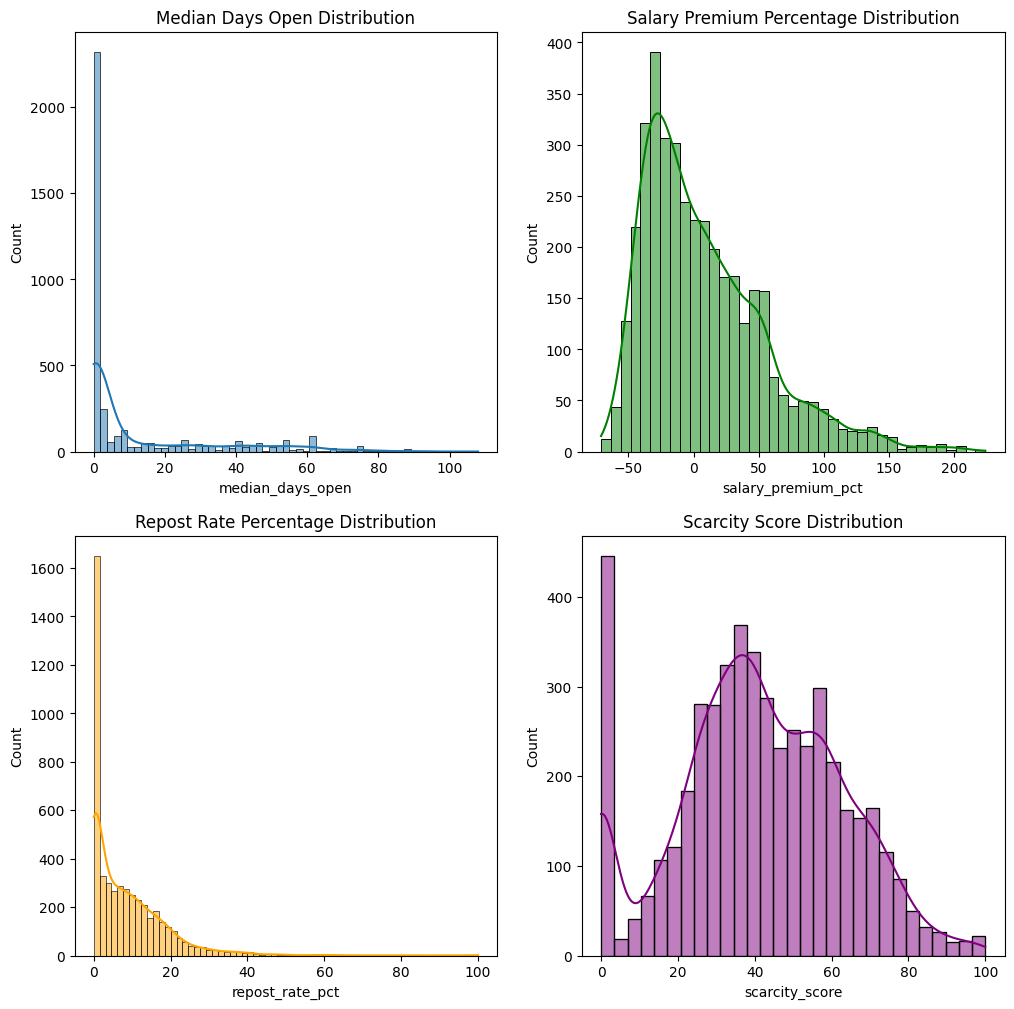

In [17]:
# Histogram Plotting
fig, ax = plt.subplots(2,2,figsize=(12,12))

# Reset index so that histogram plots can be generated without errors
# df = df.reset_index()

# median_days_open histogram
sns.histplot(data=df, x='median_days_open', ax=ax[0][0],kde=True)
ax[0][0].set_title('Median Days Open Distribution')

# salary_premium_pct histogram
sns.histplot(data=df, x='salary_premium_pct', ax=ax[0][1],kde=True, color='green')
ax[0][1].set_title('Salary Premium Percentage Distribution')

# salary_premium_pct histogram
sns.histplot(data=df, x='repost_rate_pct', ax=ax[1][0],kde=True, color='orange')
ax[1][0].set_title('Repost Rate Percentage Distribution')

# scarcity_score histogram
sns.histplot(data=df, x='scarcity_score', ax=ax[1][1],kde=True, color='purple')
ax[1][1].set_title('Scarcity Score Distribution')

With the displayed graphs above, we can see that `median_days_open`, `salary_premium_pct` and `repost_rate_pct` shows an extreme right-skewness (positive skewness) distribution of data, and bimodal distribution for `scarcity_score`

<Axes: >

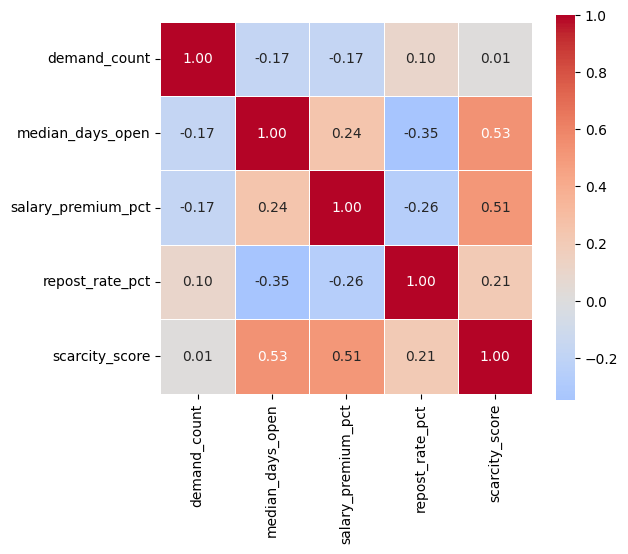

In [25]:
# CORR heatmap
cols = [
    'demand_count',
    'median_days_open',
    'salary_premium_pct',
    'repost_rate_pct',
    'scarcity_score'
]

corr = df[cols].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f",cmap="coolwarm",center=0,linewidths=0.5, square=True)

Inferences:
- `scarcity_score` and `median_days_open` have the greatests correlation, signifying that scarcer skills take significantly longer to fill.
- `scarcity_score` and `salary_premium_pct` has the second strongest correlation showing that, the scarcer the skills, the higher the salary premiums.
- `demand_count` and `scarcity_score` has the lowest value, which shows that even though the demand is high, it doesn't mean that the specified skill needed is scarce.
- `repost_rate_pct` and `salary_premium_pct` has a corr value of -0.26, which shows that frequently reposted listing tend to have lower salary premiums.

In order to back our evidences and assumptions regarding `scarcity_score` and `salary_premium_pct`, we will be using a simple Linear Regression model and evaluate it's prediction.
Since these two variables have strong relationship, we'll try if `scarcity_score` can mathematically predict `salary_premium_pct`.
This will be processed in the Modelling phase.



Next Phase after EDA is **hypothesis testing**, which is in a separate file, `02_hypothesis_testing`